# Mix noise CQT onto chord features (vivo / thinkpad / flow / thinkpad-2 / flow-2 / thinkpad-2 / flow-2)

Power-domain overlay of the ESC-50 noise bank onto **cross-domain** chord CQTs only.

- Does **not** touch `training.npz` (model stays trained on clean training features).
- Datasets: **vivo**, **thinkpad**, **flow** (ROG Flow eval; `datasets/flow` → `evaluations/test-all`, `features/flow.npz` → `evaluations/test-all.npz`).
- Writes new npz packs + a CSV manifest for reproducibility.
- Config cell controls datasets, noise class filter, SNR, and RNG.
- **Inspect** section compares clean vs mixed CQTs side-by-side.

## Config

In [1]:
from os import path
import pandas as pd
from IPython.display import display

# --- chord features to augment (non-training only) ---
# flow = original ROG Flow evaluation pack (symlink of evaluations/test-all)
CHORD_DATASETS = ["vivo", "thinkpad", "flow", "thinkpad-2", "flow-2"]
FEATURES_DIR = path.normpath("../../features")

# --- noise bank (from noise-cqt-extract.ipynb) ---
NOISE_FEATURES = path.normpath("../../features/noise/esc50-interior_domestic.npz")
# None = all classes in the bank; or e.g. ["vacuum_cleaner", "clock_tick"]
NOISE_CATEGORY_ALLOW = None

# --- mix behaviour ---
RNG_SEED = 42
SNR_DB_RANGE = (10.0, 25.0)  # uniform per sample
COPIES_PER_SAMPLE = 1        # 1 keeps same N as clean set
MIX_PROBABILITY = 1.0        # probability to mix each copy (else keep clean)
TIME_ROLL = True             # random circular shift of noise along time axis

# --- outputs ---
# {dataset} placeholder -> e.g. vivo-noise-interior_domestic.npz
OUT_NAME_TEMPLATE = "{dataset}-noise-interior_domestic.npz"
MANIFEST_NAME_TEMPLATE = "{dataset}-noise-interior_domestic.manifest.csv"
FORCE_REMIX = False  # True to overwrite existing outputs

config_df = pd.DataFrame(
    [
        {"key": "chord_datasets", "value": CHORD_DATASETS},
        {"key": "features_dir", "value": FEATURES_DIR},
        {"key": "noise_features", "value": NOISE_FEATURES},
        {"key": "noise_category_allow", "value": NOISE_CATEGORY_ALLOW},
        {"key": "snr_db_range", "value": SNR_DB_RANGE},
        {"key": "copies_per_sample", "value": COPIES_PER_SAMPLE},
        {"key": "mix_probability", "value": MIX_PROBABILITY},
        {"key": "time_roll", "value": TIME_ROLL},
        {"key": "force_remix", "value": FORCE_REMIX},
        {"key": "out_template", "value": OUT_NAME_TEMPLATE},
        {"key": "manifest_template", "value": MANIFEST_NAME_TEMPLATE},
        {"key": "rng_seed", "value": RNG_SEED},
    ]
).set_index("key")
display(config_df)

,value
key,
chord_datasets,"[vivo, thinkpad, flow, thinkpad-2, flow-2]"
features_dir,../../features
noise_features,../../features/noise/esc50-interior_domestic.npz
noise_category_allow,None
snr_db_range,"(10.0, 25.0)"
copies_per_sample,1
mix_probability,1.0
time_roll,True
force_remix,False


## Helpers

In [2]:
import csv
import numpy as np
import pandas as pd
from IPython.display import display

EPS = 1e-10


def db_to_amp(x_db):
    """Invert librosa.amplitude_to_db (ref=np.max style absolute scale per clip)."""
    return np.power(10.0, x_db.astype(np.float64) / 20.0)


def amp_to_db(x_amp):
    x = np.maximum(x_amp, EPS)
    return (20.0 * np.log10(x)).astype(np.float32)


def sample_energy(x_amp):
    return float(np.mean(np.square(x_amp)) + EPS)


def mix_power(chord_db, noise_db, snr_db, roll=0):
    """Power-domain mix: |Y|^2 ≈ |X|^2 + |N_scaled|^2, then back to dB."""
    chord_amp = db_to_amp(chord_db)
    noise_amp = db_to_amp(noise_db)
    if roll:
        noise_amp = np.roll(noise_amp, int(roll), axis=1)

    e_c = sample_energy(chord_amp)
    e_n = sample_energy(noise_amp)
    # target: 10 log10(e_c / e_n_scaled) = snr_db
    scale = np.sqrt(e_c / (e_n * (10.0 ** (snr_db / 10.0))))
    mixed_amp = np.sqrt(np.square(chord_amp) + np.square(scale * noise_amp))
    return amp_to_db(mixed_amp)


def load_noise_bank(noise_path, allow_categories):
    data = np.load(noise_path, allow_pickle=True)
    features = data["features"].astype(np.float32)
    labels = data["labels"].astype(str)
    files = data["files"].astype(str)
    if allow_categories is None:
        idx = np.arange(len(labels))
    else:
        allow = set(allow_categories)
        idx = np.array([i for i, c in enumerate(labels) if c in allow], dtype=np.int64)
        if len(idx) == 0:
            raise ValueError(f"No noise clips for categories={allow_categories}")

    meta_df = pd.DataFrame(
        [{
            "noise_path": noise_path,
            "features_shape": features.shape,
            "n_total": int(len(labels)),
            "n_usable": int(len(idx)),
            "n_classes_usable": int(len(np.unique(labels[idx]))),
            "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else "",
            "segment_mode": str(data["segment_mode"]) if "segment_mode" in data.files else "",
        }]
    )
    counts_df = (
        pd.Series(labels[idx])
        .value_counts()
        .rename_axis("category")
        .reset_index(name="n")
        .sort_values("category")
        .reset_index(drop=True)
    )
    display(meta_df)
    display(counts_df)

    return {
        "features": features,
        "labels": labels,
        "files": files,
        "idx": idx,
        "bank_tag": str(data["bank_tag"]) if "bank_tag" in data.files else "",
        "segment_mode": str(data["segment_mode"]) if "segment_mode" in data.files else "",
    }


def mix_dataset(chord_path, noise_bank, out_path, manifest_path, rng):
    chord = np.load(chord_path, allow_pickle=True)
    chord_x = chord["features"].astype(np.float32)
    chord_y = chord["labels"].astype(str)
    chord_files = chord["files"].astype(str) if "files" in chord.files else np.array(
        [f"idx_{i}" for i in range(len(chord_y))]
    )

    n = len(chord_y)
    n_out = n * COPIES_PER_SAMPLE
    out_x = np.empty((n_out, chord_x.shape[1], chord_x.shape[2]), dtype=np.float32)
    out_y = np.empty(n_out, dtype=object)
    out_files = np.empty(n_out, dtype=object)

    manifest_rows = []
    noise_idx_pool = noise_bank["idx"]
    noise_x = noise_bank["features"]
    noise_labels = noise_bank["labels"]
    noise_files = noise_bank["files"]

    k = 0
    for i in range(n):
        for copy in range(COPIES_PER_SAMPLE):
            do_mix = rng.random() < MIX_PROBABILITY
            snr = float(rng.uniform(*SNR_DB_RANGE))
            n_i = int(rng.choice(noise_idx_pool))
            roll = int(rng.integers(0, chord_x.shape[2])) if TIME_ROLL else 0

            if do_mix:
                mixed = mix_power(chord_x[i], noise_x[n_i], snr_db=snr, roll=roll)
            else:
                mixed = chord_x[i]
                snr = np.nan
                n_i = -1
                roll = 0

            out_x[k] = mixed
            out_y[k] = chord_y[i]
            out_files[k] = f"{chord_files[i]}#aug{copy}"
            manifest_rows.append({
                "out_index": k,
                "chord_index": i,
                "copy": copy,
                "chord_file": chord_files[i],
                "chord_label": chord_y[i],
                "mixed": int(do_mix),
                "noise_index": n_i,
                "noise_file": noise_files[n_i] if n_i >= 0 else "",
                "noise_category": noise_labels[n_i] if n_i >= 0 else "",
                "snr_db": snr,
                "time_roll": roll,
            })
            k += 1

    payload = {
        "features": out_x,
        "labels": np.asarray(out_y).astype(str),
        "files": np.asarray(out_files).astype(str),
        "source_chord_features": np.asarray(chord_path),
        "source_noise_features": np.asarray(NOISE_FEATURES),
        "snr_db_range": np.asarray(SNR_DB_RANGE, dtype=np.float32),
        "rng_seed": np.asarray(RNG_SEED),
        "copies_per_sample": np.asarray(COPIES_PER_SAMPLE),
        "mix_probability": np.asarray(MIX_PROBABILITY),
        "time_roll": np.asarray(TIME_ROLL),
        "noise_bank_tag": np.asarray(noise_bank["bank_tag"]),
    }
    np.savez_compressed(out_path, **payload)

    with open(manifest_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(manifest_rows[0].keys()))
        writer.writeheader()
        writer.writerows(manifest_rows)

    return {
        "n_in": n,
        "n_out": n_out,
        "n_mixed": int(sum(r["mixed"] for r in manifest_rows)),
        "out_path": out_path,
        "manifest_path": manifest_path,
        "shape": out_x.shape,
    }

display(pd.DataFrame([{"helpers": "ready"}]))

,helpers
0,ready


## Run mix

In [3]:
import pandas as pd
from IPython.display import display

assert path.isfile(NOISE_FEATURES), f"Missing noise bank: {NOISE_FEATURES}"
for name in CHORD_DATASETS:
    assert name != "training", "Do not mix noise into training features"
    chord_path = path.join(FEATURES_DIR, f"{name}.npz")
    assert path.isfile(chord_path) or path.islink(chord_path), f"Missing chord features: {chord_path}"

noise_bank = load_noise_bank(NOISE_FEATURES, NOISE_CATEGORY_ALLOW)

# Stable per-dataset seeds (avoid PYTHONHASHSEED nondeterminism)
DATASET_SEED_OFFSET = {"vivo": 1, "thinkpad": 2, "flow": 3, "thinkpad-2": 4, "flow-2": 5}

results = []
for name in CHORD_DATASETS:
    chord_path = path.join(FEATURES_DIR, f"{name}.npz")
    out_path = path.join(FEATURES_DIR, OUT_NAME_TEMPLATE.format(dataset=name))
    manifest_path = path.join(FEATURES_DIR, MANIFEST_NAME_TEMPLATE.format(dataset=name))

    if path.isfile(out_path) and not FORCE_REMIX:
        data = np.load(out_path, allow_pickle=True)
        results.append({
            "dataset": name,
            "status": "skipped_exists",
            "n_in": None,
            "n_out": int(data["features"].shape[0]),
            "n_mixed": None,
            "shape": data["features"].shape,
            "out_path": out_path,
            "manifest_path": manifest_path if path.isfile(manifest_path) else None,
        })
        continue

    offset = DATASET_SEED_OFFSET.get(name, 100 + CHORD_DATASETS.index(name))
    ds_rng = np.random.default_rng(RNG_SEED + offset)
    info = mix_dataset(chord_path, noise_bank, out_path, manifest_path, ds_rng)
    results.append({
        "dataset": name,
        "status": "mixed",
        "n_in": info["n_in"],
        "n_out": info["n_out"],
        "n_mixed": info["n_mixed"],
        "shape": info["shape"],
        "out_path": info["out_path"],
        "manifest_path": info["manifest_path"],
    })

results_df = pd.DataFrame(results)
display(results_df)

,noise_path,features_shape,n_total,n_usable,n_classes_usable,bank_tag,segment_mode
0,../../features/noise/esc50-interior_domestic.npz,"(400, 216, 188)",400,400,10,interior_domestic,max_energy


,category,n
0,can_opening,40
1,clock_alarm,40
2,clock_tick,40
3,door_wood_creaks,40
4,door_wood_knock,40
5,glass_breaking,40
6,keyboard_typing,40
7,mouse_click,40
8,vacuum_cleaner,40
9,washing_machine,40


,dataset,status,n_in,n_out,n_mixed,shape,out_path,manifest_path
0,vivo,skipped_exists,NaN,1440,NaN,"(1440, 216, 188)",../../features/vivo-noise-interior_domestic.npz,../../features/vivo-noise-interior_domestic.ma...
1,thinkpad,skipped_exists,NaN,1440,NaN,"(1440, 216, 188)",../../features/thinkpad-noise-interior_domesti...,../../features/thinkpad-noise-interior_domesti...
2,flow,skipped_exists,NaN,1440,NaN,"(1440, 216, 188)",../../features/flow-noise-interior_domestic.npz,../../features/flow-noise-interior_domestic.ma...
3,thinkpad-2,mixed,720.0,720,720.0,"(720, 216, 188)",../../features/thinkpad-2-noise-interior_domes...,../../features/thinkpad-2-noise-interior_domes...
4,flow-2,mixed,1440.0,1440,1440.0,"(1440, 216, 188)",../../features/flow-2-noise-interior_domestic.npz,../../features/flow-2-noise-interior_domestic....


## Verify

In [4]:
import pandas as pd
from IPython.display import display

summary_rows = []
category_frames = []

for name in CHORD_DATASETS:
    out_path = path.join(FEATURES_DIR, OUT_NAME_TEMPLATE.format(dataset=name))
    manifest_path = path.join(FEATURES_DIR, MANIFEST_NAME_TEMPLATE.format(dataset=name))
    clean_path = path.join(FEATURES_DIR, f"{name}.npz")

    clean = np.load(clean_path, allow_pickle=True)
    mixed = np.load(out_path, allow_pickle=True)
    man = pd.read_csv(manifest_path)
    mixed_only = man.loc[man["mixed"] == 1]

    summary_rows.append({
        "dataset": name,
        "clean_shape": clean["features"].shape,
        "mixed_shape": mixed["features"].shape,
        "n_classes": int(len(np.unique(mixed["labels"]))),
        "labels_match_clean": set(mixed["labels"].astype(str)) == set(clean["labels"].astype(str)),
        "mixed_fraction": float(man["mixed"].mean()),
        "snr_mean": float(mixed_only["snr_db"].mean()) if len(mixed_only) else np.nan,
        "snr_std": float(mixed_only["snr_db"].std()) if len(mixed_only) else np.nan,
        "ms_db_clean_head32": float(np.mean(clean["features"][:32] ** 2)),
        "ms_db_mixed_head32": float(np.mean(mixed["features"][:32] ** 2)),
    })

    cat = (
        mixed_only["noise_category"]
        .value_counts()
        .rename_axis("noise_category")
        .reset_index(name="n")
        .assign(dataset=name)
    )
    category_frames.append(cat)

summary_df = pd.DataFrame(summary_rows)
noise_usage_df = pd.concat(category_frames, ignore_index=True)
noise_usage_wide = (
    noise_usage_df.pivot(index="noise_category", columns="dataset", values="n")
    .fillna(0)
    .astype(int)
    .sort_index()
)

display(summary_df)
display(noise_usage_wide)

,dataset,clean_shape,mixed_shape,n_classes,labels_match_clean,mixed_fraction,snr_mean,snr_std,ms_db_clean_head32,ms_db_mixed_head32
0,vivo,"(1440, 216, 188)","(1440, 216, 188)",36,True,1.0,17.498766,4.298353,4365.304688,3177.911865
1,thinkpad,"(1440, 216, 188)","(1440, 216, 188)",36,True,1.0,17.652126,4.359010,3164.250000,2612.183105
2,flow,"(1440, 216, 188)","(1440, 216, 188)",36,True,1.0,17.374167,4.295825,1912.605225,1595.738403
3,thinkpad-2,"(720, 216, 188)","(720, 216, 188)",36,True,1.0,17.171327,4.401992,2174.795410,1833.698608
4,flow-2,"(1440, 216, 188)","(1440, 216, 188)",36,True,1.0,17.828338,4.311719,2269.234131,1941.085693


dataset,flow,flow-2,thinkpad,thinkpad-2,vivo
noise_category,,,,,
can_opening,140,131,132,76,144
clock_alarm,134,149,148,80,142
clock_tick,145,136,130,76,124
door_wood_creaks,150,160,150,76,155
door_wood_knock,127,143,131,67,162
glass_breaking,145,136,165,60,138
keyboard_typing,141,147,137,66,145
mouse_click,160,153,148,71,141
vacuum_cleaner,147,146,146,70,141


## Inspect clean vs mixed

Random samples from a mixed pack: clean CQT | mixed CQT | difference (`mixed − clean`). Manifest columns show which noise clip and SNR were applied.

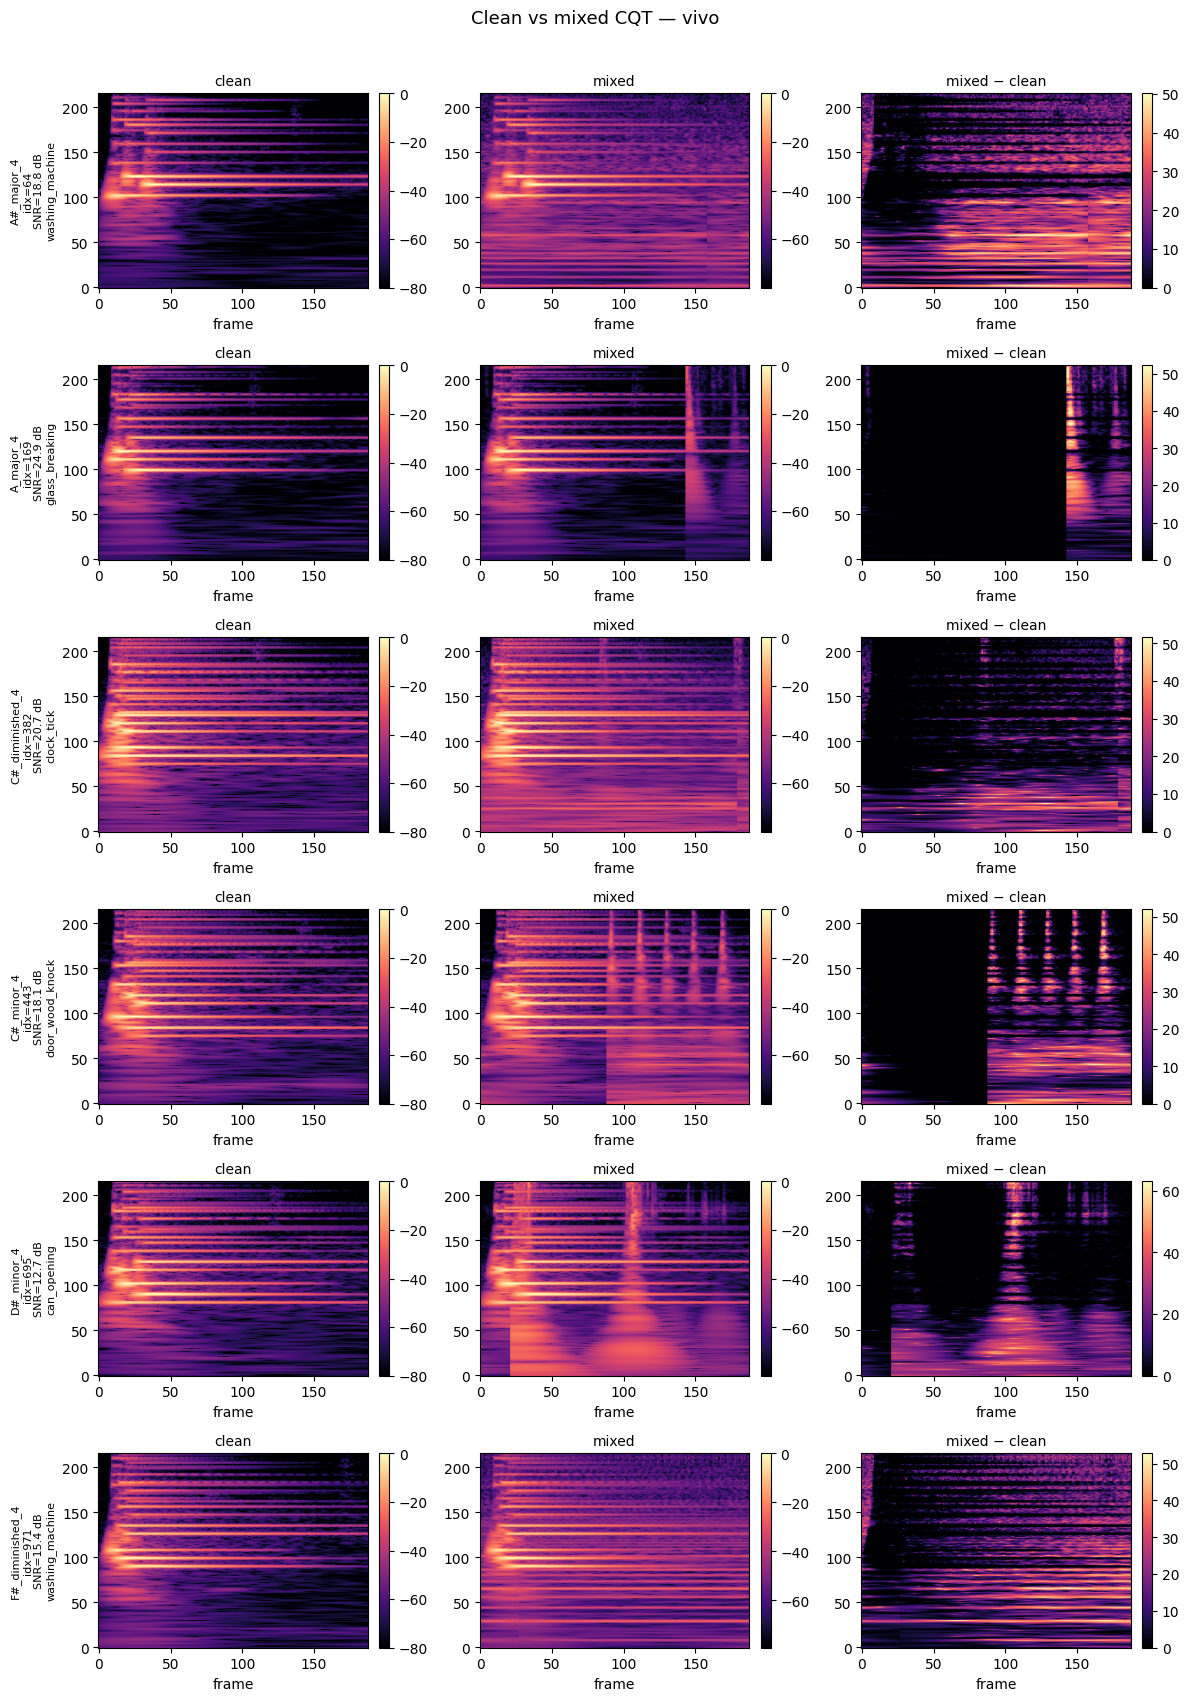

,dataset,out_index,chord_index,chord_label,chord_file,noise_category,noise_file,snr_db,time_roll,mixed
0,vivo,64,64,A#_major_4,A#_major_4/A#_major_4-31.wav,washing_machine,4-218199-C-35.wav,18.815596,158,1
1,vivo,169,169,A_major_4,A_major_4/A_major_4-18.wav,glass_breaking,5-260432-A-39.wav,24.863429,143,1
2,vivo,382,382,C#_diminished_4,C#_diminished_4/C#_diminished_4-3.wav,clock_tick,4-181865-A-38.wav,20.657658,179,1
3,vivo,443,443,C#_minor_4,C#_minor_4/C#_minor_4-12.wav,door_wood_knock,1-103995-A-30.wav,18.138659,88,1
4,vivo,695,695,D#_minor_4,D#_minor_4/D#_minor_4-23.wav,can_opening,4-264453-A-34.wav,12.661056,21,1
5,vivo,971,971,F#_diminished_4,F#_diminished_4/F#_diminished_4-2.wav,washing_machine,1-32373-A-35.wav,15.432471,27,1


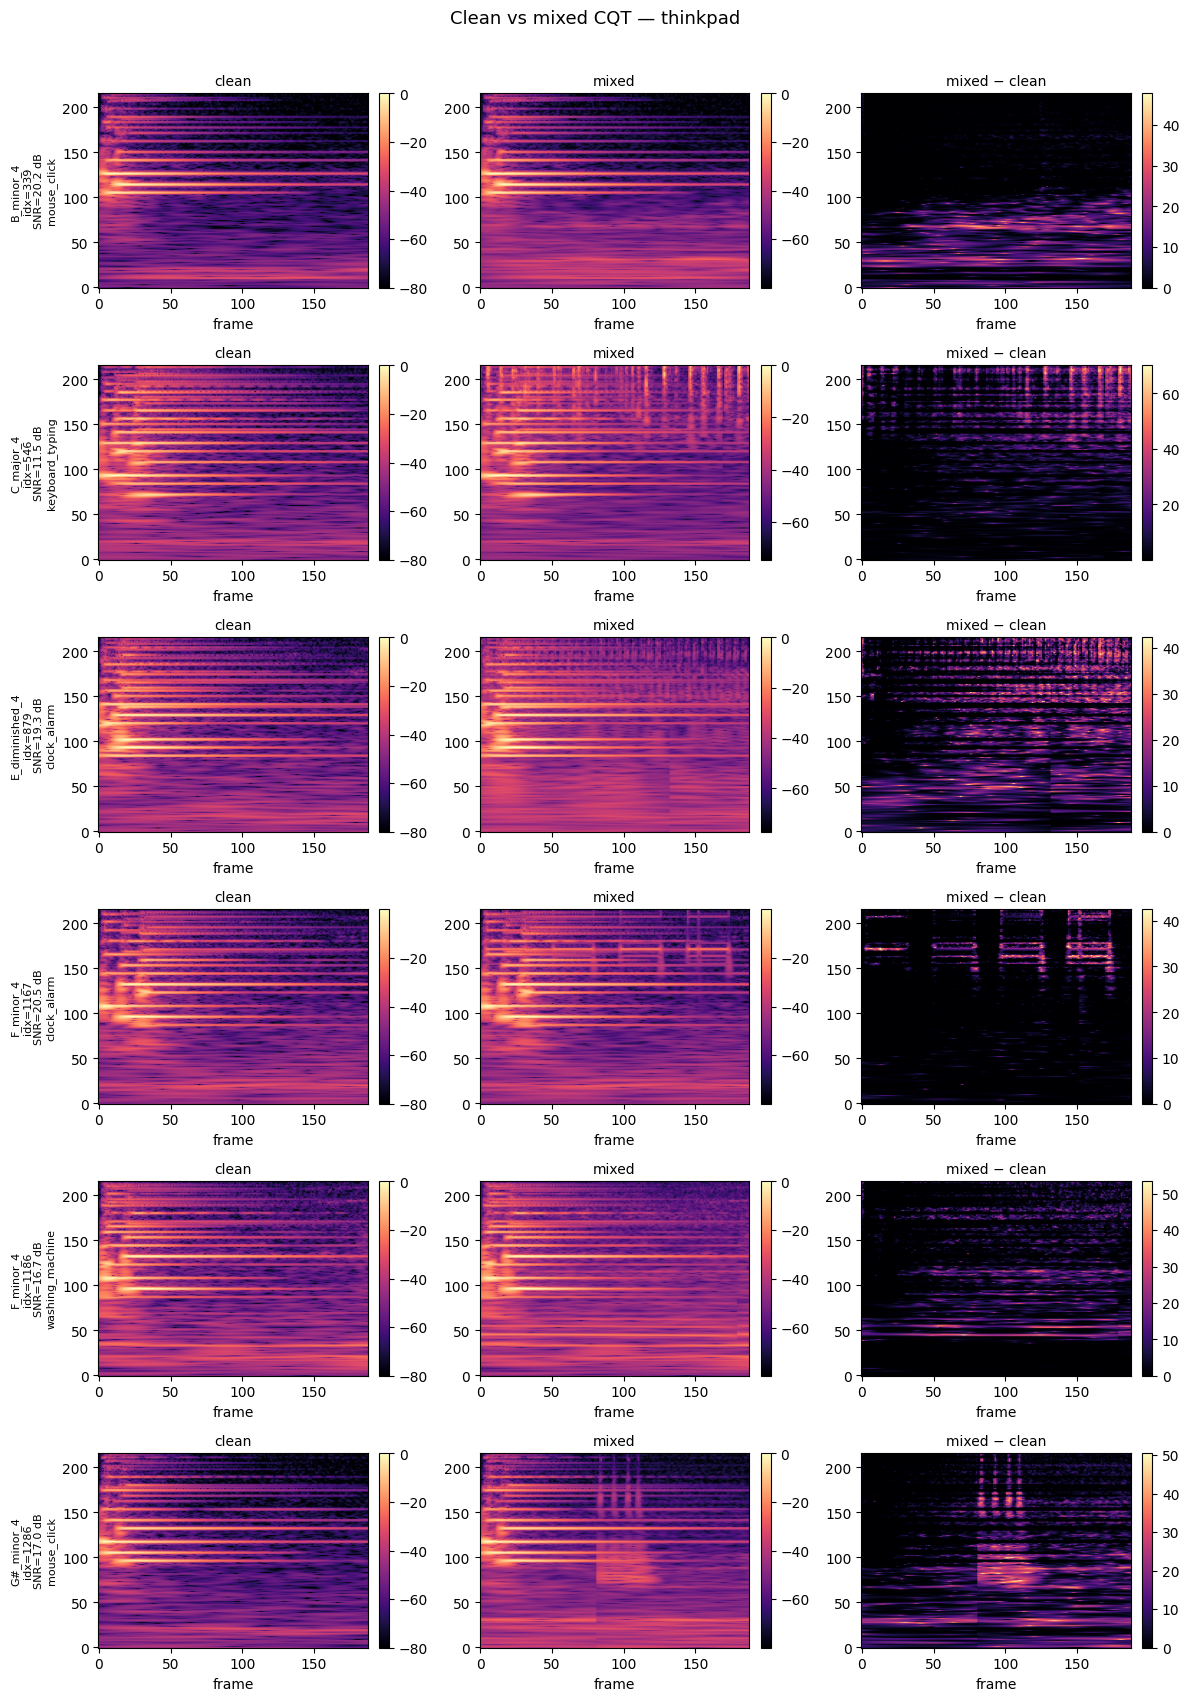

,dataset,out_index,chord_index,chord_label,chord_file,noise_category,noise_file,snr_db,time_roll,mixed
0,thinkpad,339,339,B_minor_4,B_minor_4/B_minor_4-27.wav,mouse_click,1-85123-A-31.wav,20.232962,1,1
1,thinkpad,546,546,C_major_4,C_major_4/C_major_4-33.wav,keyboard_typing,1-53501-A-32.wav,11.501072,169,1
2,thinkpad,879,879,E_diminished_4,E_diminished_4/E_diminished_4-9.wav,clock_alarm,3-139958-A-37.wav,19.313098,132,1
3,thinkpad,1167,1167,F_minor_4,F_minor_4/F_minor_4-16.wav,clock_alarm,1-96890-A-37.wav,20.455534,152,1
4,thinkpad,1186,1186,F_minor_4,F_minor_4/F_minor_4-33.wav,washing_machine,3-156391-A-35.wav,16.702858,179,1
5,thinkpad,1286,1286,G#_minor_4,G#_minor_4/G#_minor_4-15.wav,mouse_click,2-138257-A-31.wav,16.985475,81,1


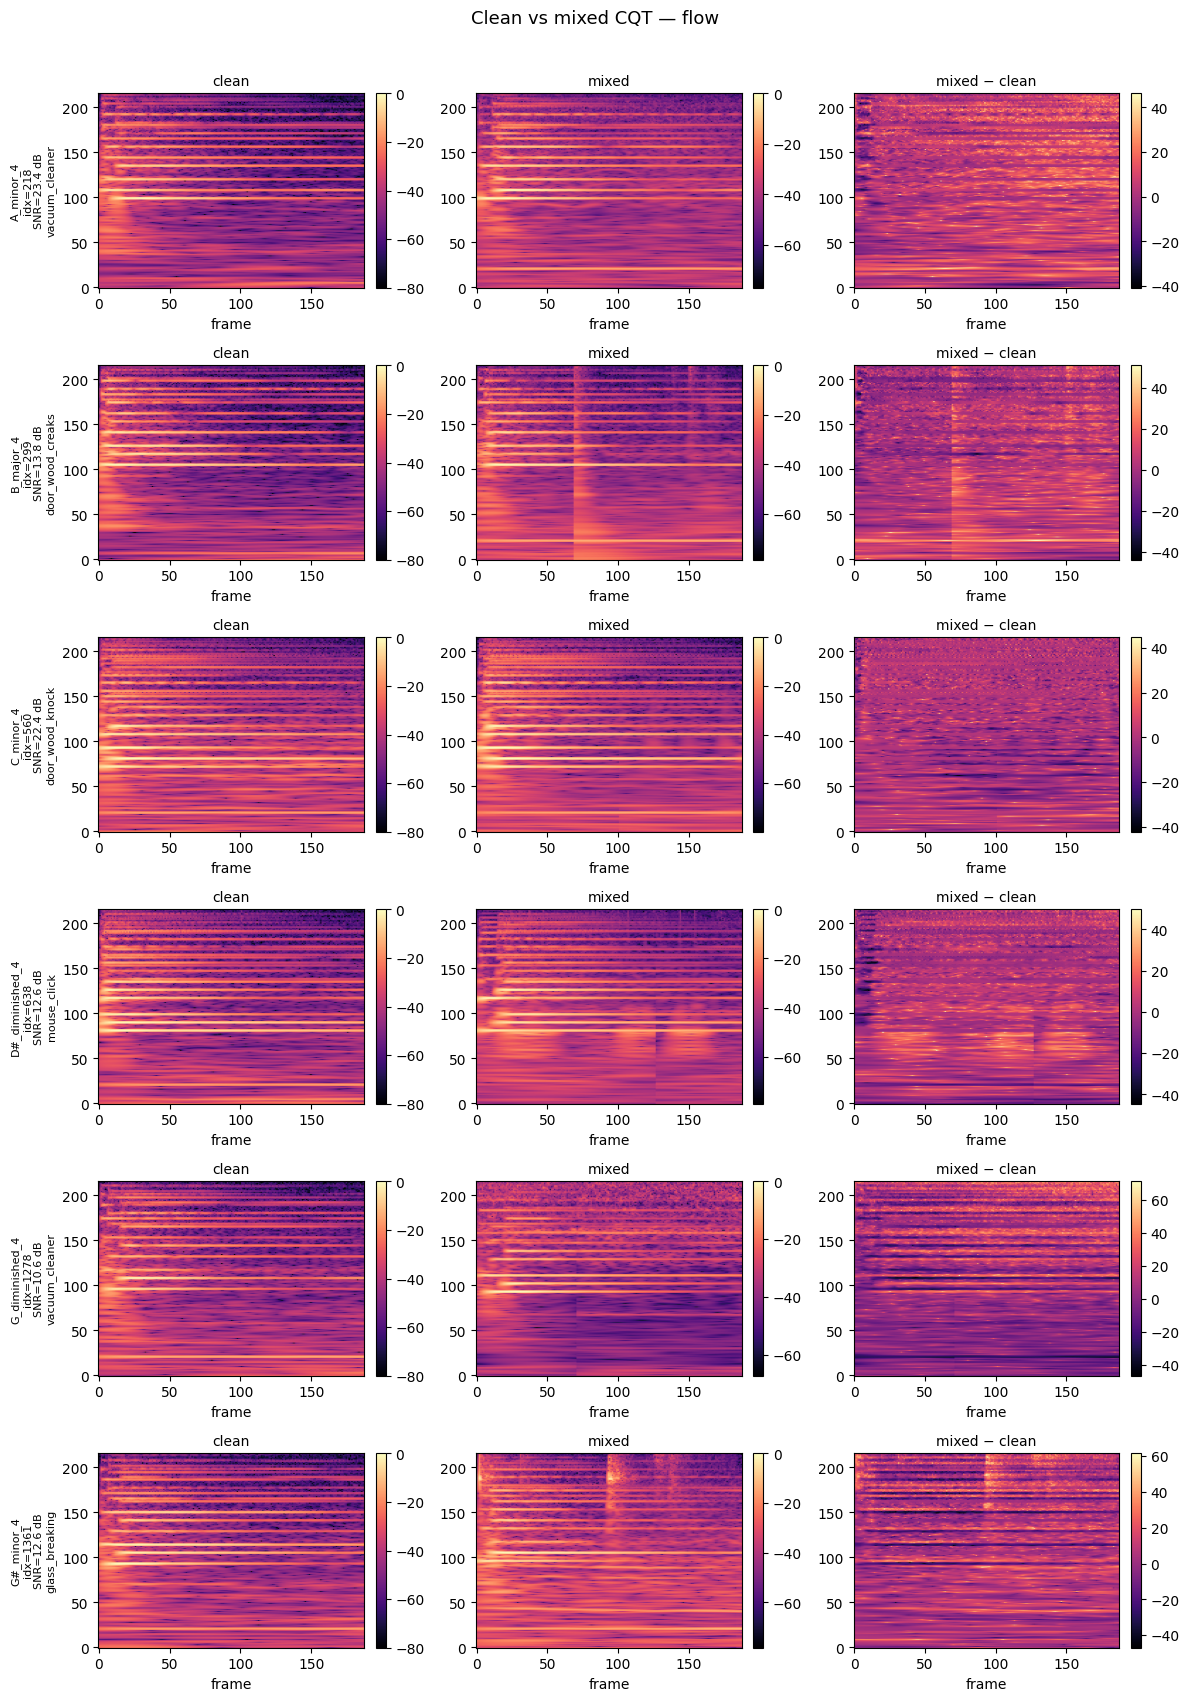

,dataset,out_index,chord_index,chord_label,chord_file,noise_category,noise_file,snr_db,time_roll,mixed
0,flow,218,218,A_minor_4,idx_218,vacuum_cleaner,3-159347-B-36.wav,23.412814,21,1
1,flow,299,299,B_major_4,idx_299,door_wood_creaks,5-181458-A-33.wav,13.832731,69,1
2,flow,560,560,C_minor_4,idx_560,door_wood_knock,2-133889-A-30.wav,22.391163,101,1
3,flow,638,638,D#_diminished_4,idx_638,mouse_click,5-237315-A-31.wav,12.614992,127,1
4,flow,1278,1278,G_diminished_4,idx_1278,vacuum_cleaner,5-212059-A-36.wav,10.551353,71,1
5,flow,1361,1361,G#_minor_4,idx_1361,glass_breaking,2-250710-A-39.wav,12.600112,184,1


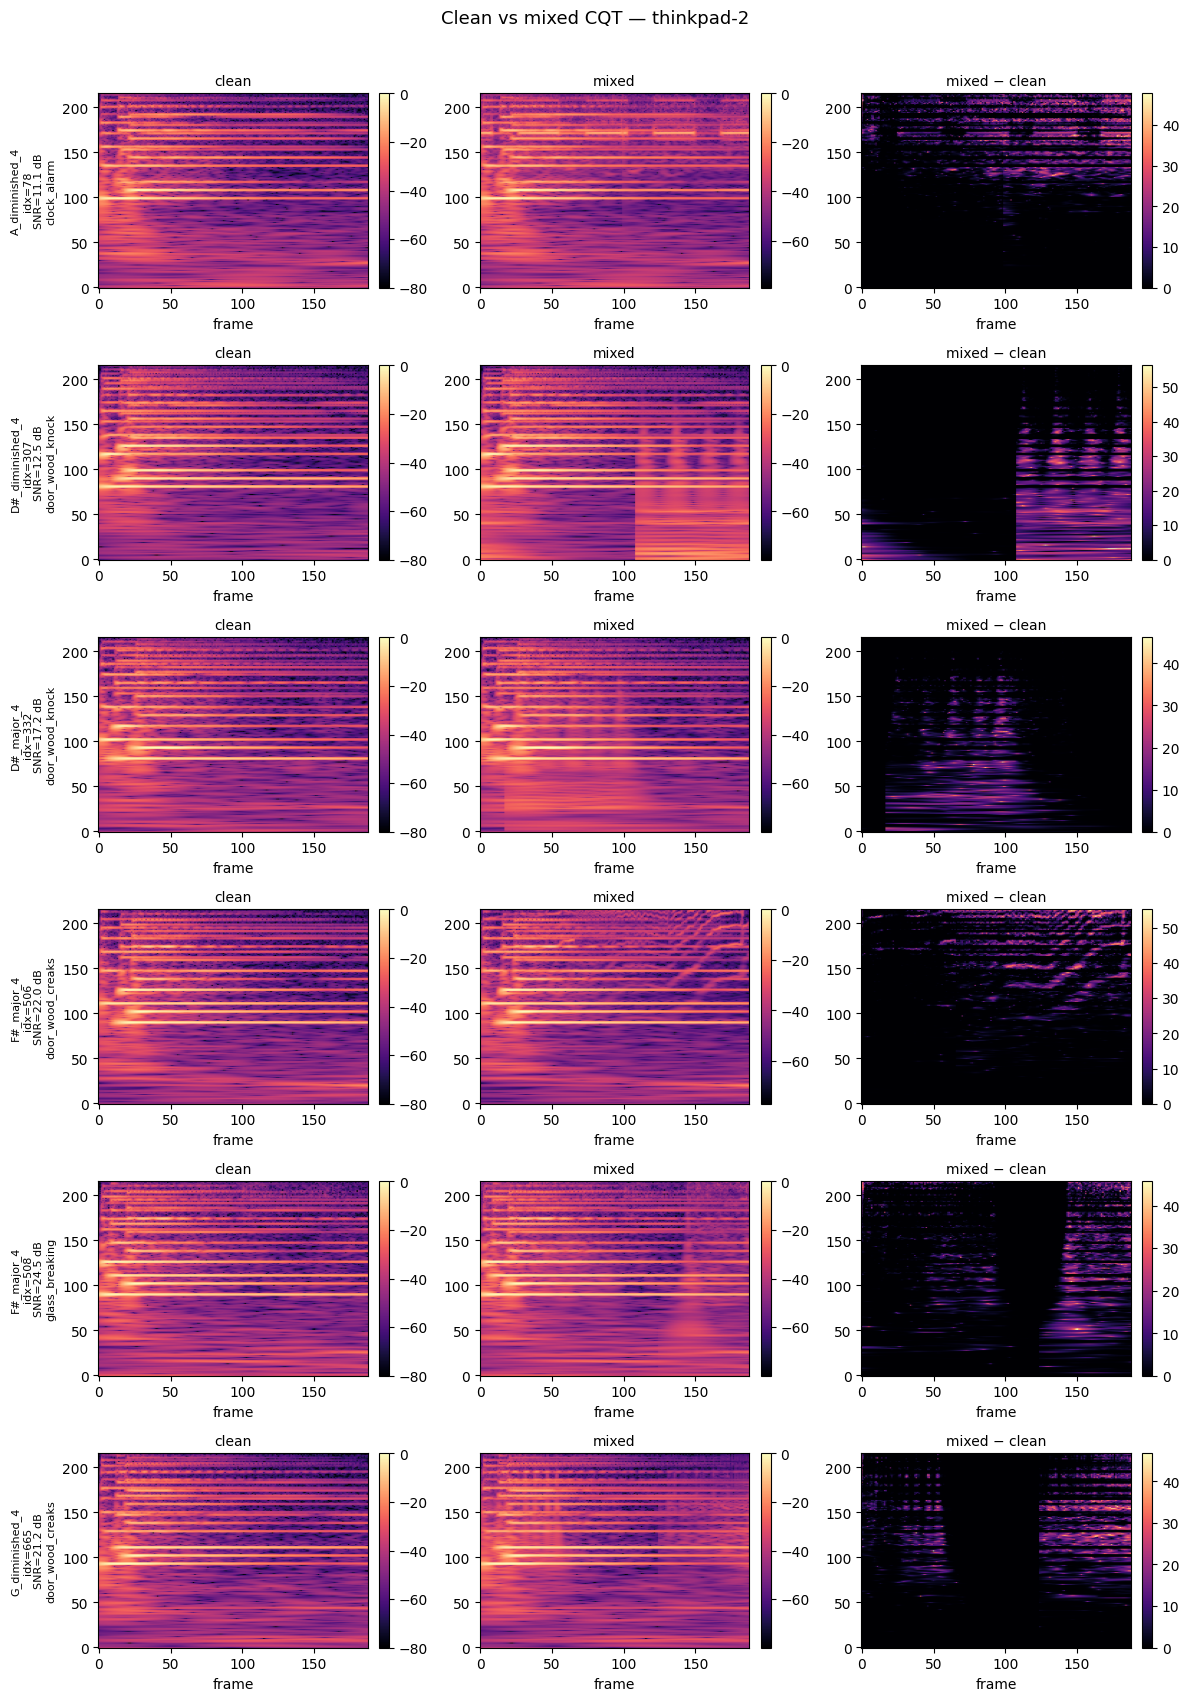

,dataset,out_index,chord_index,chord_label,chord_file,noise_category,noise_file,snr_db,time_roll,mixed
0,thinkpad-2,78,78,A_diminished_4,A_diminished_4/A_diminished_4-8.wav,clock_alarm,5-234247-A-37.wav,11.060109,99,1
1,thinkpad-2,307,307,D#_diminished_4,D#_diminished_4/D#_diminished_4-16.wav,door_wood_knock,4-182039-A-30.wav,12.500993,108,1
2,thinkpad-2,332,332,D#_major_4,D#_major_4/D#_major_4-20.wav,door_wood_knock,4-182041-A-30.wav,17.238686,17,1
3,thinkpad-2,506,506,F#_major_4,F#_major_4/F#_major_4-15.wav,door_wood_creaks,4-107122-A-33.wav,22.031992,66,1
4,thinkpad-2,508,508,F#_major_4,F#_major_4/F#_major_4-17.wav,glass_breaking,2-141563-A-39.wav,24.523039,124,1
5,thinkpad-2,665,665,G_diminished_4,G_diminished_4/G_diminished_4-14.wav,door_wood_creaks,3-101381-A-33.wav,21.184851,124,1


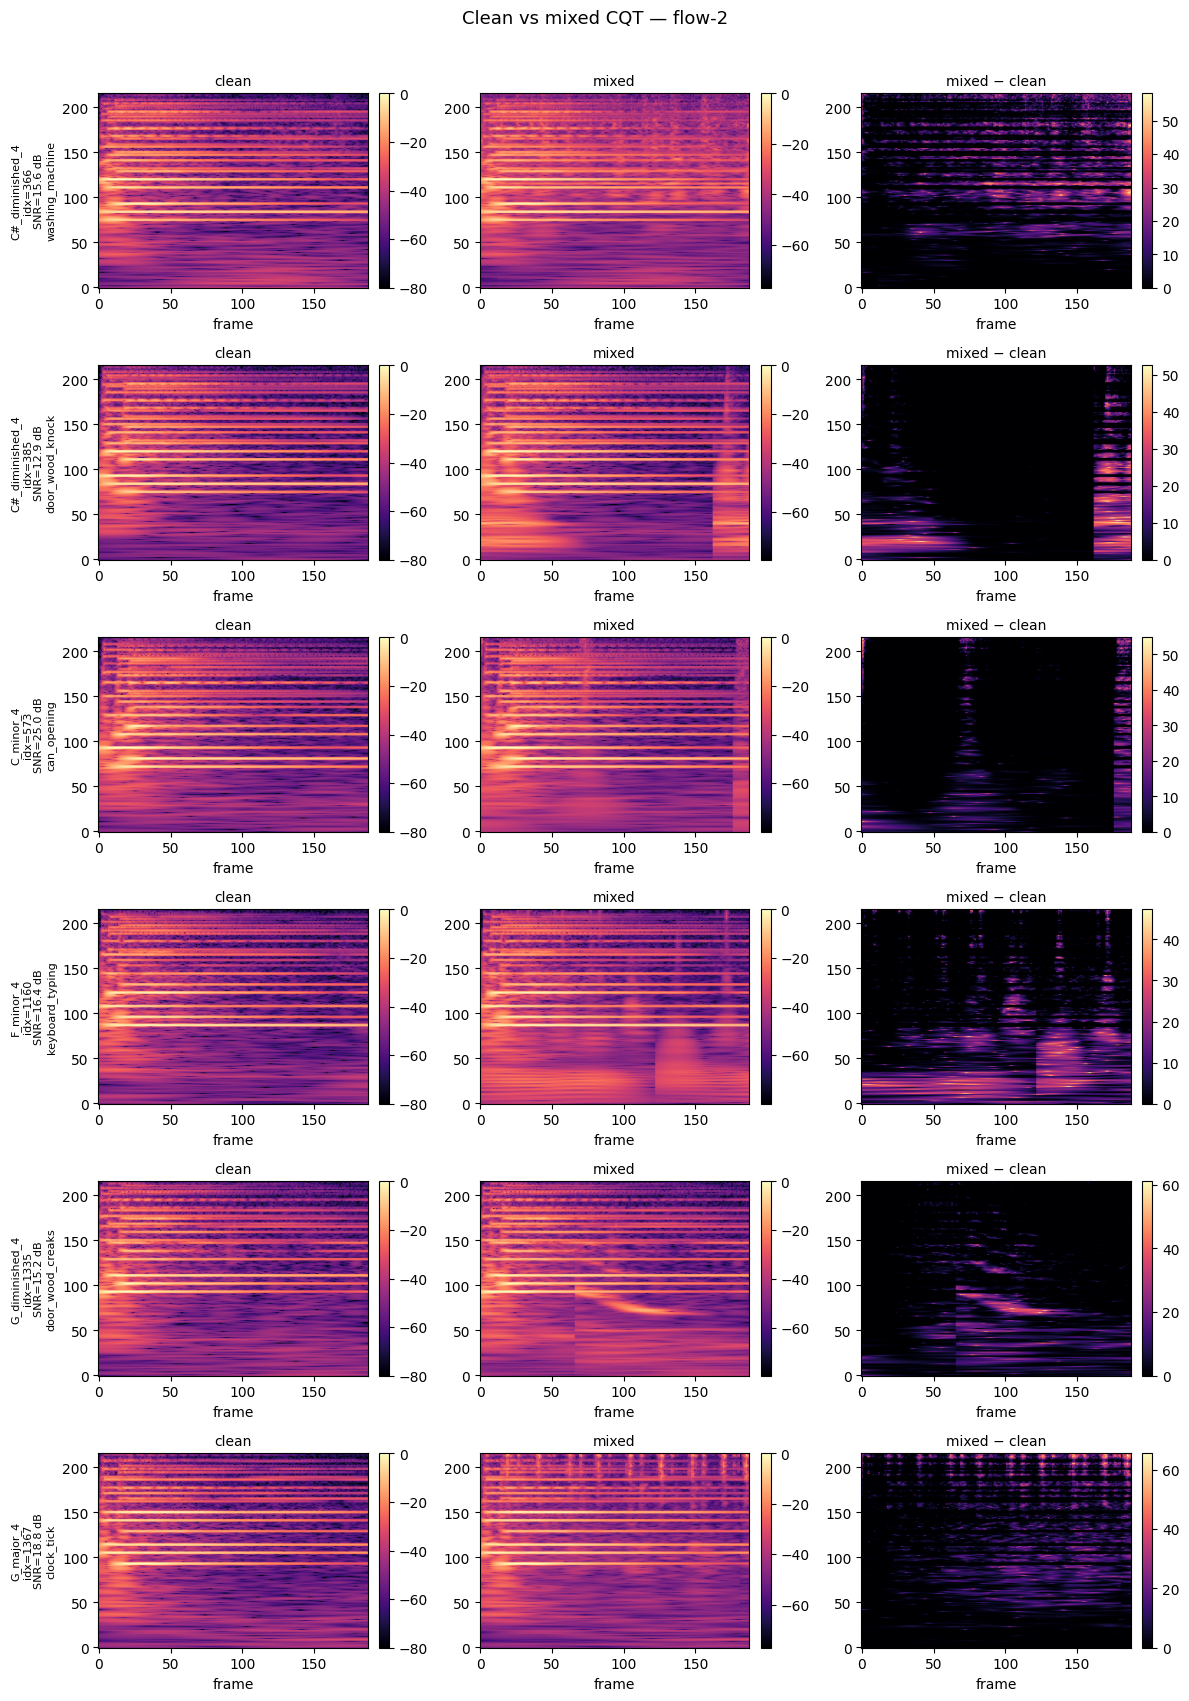

,dataset,out_index,chord_index,chord_label,chord_file,noise_category,noise_file,snr_db,time_roll,mixed
0,flow-2,366,366,C#_diminished_4,C#_diminished_4/C#_diminished_4-15.wav,washing_machine,5-181977-A-35.wav,15.569996,12,1
1,flow-2,385,385,C#_diminished_4,C#_diminished_4/C#_diminished_4-32.wav,door_wood_knock,2-118624-A-30.wav,12.856180,162,1
2,flow-2,573,573,C_minor_4,C_minor_4/C_minor_4-21.wav,can_opening,4-264453-A-34.wav,24.975923,176,1
3,flow-2,1160,1160,F_minor_4,F_minor_4/F_minor_4-1.wav,keyboard_typing,1-62594-A-32.wav,16.406125,122,1
4,flow-2,1335,1335,G_diminished_4,G_diminished_4/G_diminished_4-23.wav,door_wood_creaks,4-160036-B-33.wav,15.197441,66,1
5,flow-2,1367,1367,G_major_4,G_major_4/G_major_4-16.wav,clock_tick,3-142593-A-38.wav,18.837337,181,1


,dataset,out_index,chord_index,chord_label,chord_file,noise_category,noise_file,snr_db,time_roll,mixed
0,vivo,64,64,A#_major_4,A#_major_4/A#_major_4-31.wav,washing_machine,4-218199-C-35.wav,18.815596,158,1
1,vivo,169,169,A_major_4,A_major_4/A_major_4-18.wav,glass_breaking,5-260432-A-39.wav,24.863429,143,1
2,vivo,382,382,C#_diminished_4,C#_diminished_4/C#_diminished_4-3.wav,clock_tick,4-181865-A-38.wav,20.657658,179,1
3,vivo,443,443,C#_minor_4,C#_minor_4/C#_minor_4-12.wav,door_wood_knock,1-103995-A-30.wav,18.138659,88,1
4,vivo,695,695,D#_minor_4,D#_minor_4/D#_minor_4-23.wav,can_opening,4-264453-A-34.wav,12.661056,21,1
5,vivo,971,971,F#_diminished_4,F#_diminished_4/F#_diminished_4-2.wav,washing_machine,1-32373-A-35.wav,15.432471,27,1
6,thinkpad,339,339,B_minor_4,B_minor_4/B_minor_4-27.wav,mouse_click,1-85123-A-31.wav,20.232962,1,1
7,thinkpad,546,546,C_major_4,C_major_4/C_major_4-33.wav,keyboard_typing,1-53501-A-32.wav,11.501072,169,1
8,thinkpad,879,879,E_diminished_4,E_diminished_4/E_diminished_4-9.wav,clock_alarm,3-139958-A-37.wav,19.313098,132,1
9,thinkpad,1167,1167,F_minor_4,F_minor_4/F_minor_4-16.wav,clock_alarm,1-96890-A-37.wav,20.455534,152,1


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# --- inspect config ---
INSPECT_DATASETS = list(CHORD_DATASETS)  # all packs: vivo / thinkpad / flow / thinkpad-2 / flow-2
INSPECT_N = 6
INSPECT_SEED = 0
# None = any; or e.g. ["vacuum_cleaner", "keyboard_typing"]
INSPECT_NOISE_CATEGORIES = None

all_sample_frames = []

for INSPECT_DATASET in INSPECT_DATASETS:
    clean_path = path.join(FEATURES_DIR, f"{INSPECT_DATASET}.npz")
    mixed_path = path.join(FEATURES_DIR, OUT_NAME_TEMPLATE.format(dataset=INSPECT_DATASET))
    manifest_path = path.join(
        FEATURES_DIR, MANIFEST_NAME_TEMPLATE.format(dataset=INSPECT_DATASET)
    )

    clean = np.load(clean_path, allow_pickle=True)
    mixed = np.load(mixed_path, allow_pickle=True)
    man = pd.read_csv(manifest_path)

    clean_x = clean["features"]
    mixed_x = mixed["features"]

    # align manifest to mixed indices (out_index)
    man = man.sort_values("out_index").reset_index(drop=True)
    assert len(man) == len(mixed_x), f"{INSPECT_DATASET}: manifest length must match mixed features"

    pool = man.index.to_numpy()
    if INSPECT_NOISE_CATEGORIES is not None:
        allow = set(INSPECT_NOISE_CATEGORIES)
        pool = man.index[man["noise_category"].isin(allow)].to_numpy()
        if len(pool) == 0:
            raise ValueError(
                f"{INSPECT_DATASET}: no rows for INSPECT_NOISE_CATEGORIES={INSPECT_NOISE_CATEGORIES}"
            )

    # stable per-dataset seed so re-runs are comparable
    rng = np.random.default_rng(INSPECT_SEED + hash(INSPECT_DATASET) % 10_000)
    n_show = min(INSPECT_N, len(pool))
    out_idx = np.sort(rng.choice(pool, size=n_show, replace=False))

    rows = n_show
    cols = 3  # clean | mixed | diff
    fig, axes = plt.subplots(rows, cols, figsize=(12, 2.8 * rows), squeeze=False)

    for r, i in enumerate(out_idx):
        chord_i = int(man.loc[i, "chord_index"])
        c = clean_x[chord_i]
        m = mixed_x[i]
        d = m.astype(np.float32) - c.astype(np.float32)

        for ax, img, title in zip(
            axes[r],
            [c, m, d],
            ["clean", "mixed", "mixed − clean"],
        ):
            im = ax.imshow(img, origin="lower", aspect="auto", cmap="magma")
            ax.set_title(title, fontsize=10)
            ax.set_ylabel("bin" if title == "clean" else "")
            ax.set_xlabel("frame")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        snr = man.loc[i, "snr_db"]
        noise_cat = man.loc[i, "noise_category"]
        chord_lab = man.loc[i, "chord_label"]
        axes[r, 0].set_ylabel(
            f"{chord_lab}\nidx={i}\nSNR={snr:.1f} dB\n{noise_cat}",
            fontsize=8,
        )

    fig.suptitle(
        f"Clean vs mixed CQT — {INSPECT_DATASET}",
        fontsize=13,
        y=1.01,
    )
    fig.tight_layout()
    plt.show()

    sample_df = man.loc[
        out_idx,
        [
            "out_index",
            "chord_index",
            "chord_label",
            "chord_file",
            "noise_category",
            "noise_file",
            "snr_db",
            "time_roll",
            "mixed",
        ],
    ].copy()
    sample_df.insert(0, "dataset", INSPECT_DATASET)
    sample_df = sample_df.reset_index(drop=True)
    display(sample_df)
    all_sample_frames.append(sample_df)

display(pd.concat(all_sample_frames, ignore_index=True))